# Uniaxial Plasticity: Cycling

This notebook investigates uniaxial plasticity models that are included in OpenSees/Xara.


In [1]:
#<hide>
import matplotlib.pyplot as plt
plt.style.use("thesis")
del plt

In [2]:
from numpy import sin, linspace, pi
import numpy as np
import matplotlib.pyplot as plt

For convenience, import unit constants from the {ref}`units` submodule and define parameters.

In [3]:
from xara.units.english import ksi, psi

Fy  = 66.8*ksi           # steel yield stress
Es  = 29e3*ksi           # modulus of steel
Hiso = 0.01*Es           # isotropic hardening modulus
Fs = 90*ksi
bi = 15

Next, create the {py:class}`xara.UniaxialMaterial`.

In [4]:
import xara 

Materials = {
    # "Steel02": xara.UniaxialMaterial(
    #     type="Steel02",
    #     E=Es,
    #     Fy=Fy,
    #     b=Hiso/Es
    # ),

    "PlasticJ2 (LP)": xara.UniaxialMaterial("Continuum", 
        xara.MultiaxialMaterial("PlasticJ2",
            E=Es, 
            nu = 0.3,
            Fy = Fy,
            Hiso = Hiso,
        ),
    ),
    "PlasticJ2 (NI)": xara.UniaxialMaterial("Continuum", 
        xara.MultiaxialMaterial("PlasticJ2",
            E=Es, 
            nu = 0.3,
            Fy = Fy,
            Hiso = Hiso,
            Fs = Fs,
            b=bi
        ),
    ),
    "GeneralizedJ2 (LP)": xara.UniaxialMaterial("Continuum", 
        xara.MultiaxialMaterial("GeneralizedJ2",
            E=Es, 
            nu = 0.3,
            Fy = Fy,
            Hiso = Hiso
        ),
    ),
    "GeneralizedJ2 (GP)": xara.UniaxialMaterial("Continuum", 
        xara.MultiaxialMaterial("GeneralizedJ2",
            E=Es, 
            nu = 0.3,
            Fy = Fy,
            Hiso = Hiso,
            overstress=Fs,
            transition=0.1
        ),
    )
}


for name,mat in Materials.items():
    print(name)
    print(mat.asdict(full_data=True))


PlasticJ2 (LP)
{'StructuralAnalysisModel': {'properties': {'sections': [], 'nDMaterials': [{'name': 1, 'type': 'NonlinearJ2', 'E': 29000000.0, 'nu': 0.3, 'Fy': 66800, 'Q': [0, 0], 'b': [0, 0], 'C': [0], 'gamma': [0], 'Hiso': 290000, 'gtol': 1e-16, 'MaxIter': 15, 'density': 0}], 'uniaxialMaterials': [{'name': 2, 'type': 'ContinuumUniaxial', 'material': 1}], 'crdTransformations': [], 'patterns': [], 'damping': {}, 'parameters': []}, 'geometry': {'nodes': [], 'elements': [], 'constraints': []}}}
PlasticJ2 (NI)
{'StructuralAnalysisModel': {'properties': {'sections': [], 'nDMaterials': [{'name': 1, 'type': 'NonlinearJ2', 'E': 29000000.0, 'nu': 0.3, 'Fy': 66800, 'Q': [23200, 0], 'b': [15, 0], 'C': [0], 'gamma': [0], 'Hiso': 290000, 'gtol': 1e-16, 'MaxIter': 15, 'density': 0}], 'uniaxialMaterials': [{'name': 2, 'type': 'ContinuumUniaxial', 'material': 1}], 'crdTransformations': [], 'patterns': [], 'damping': {}, 'parameters': []}, 'geometry': {'nodes': [], 'elements': [], 'constraints': []}}}

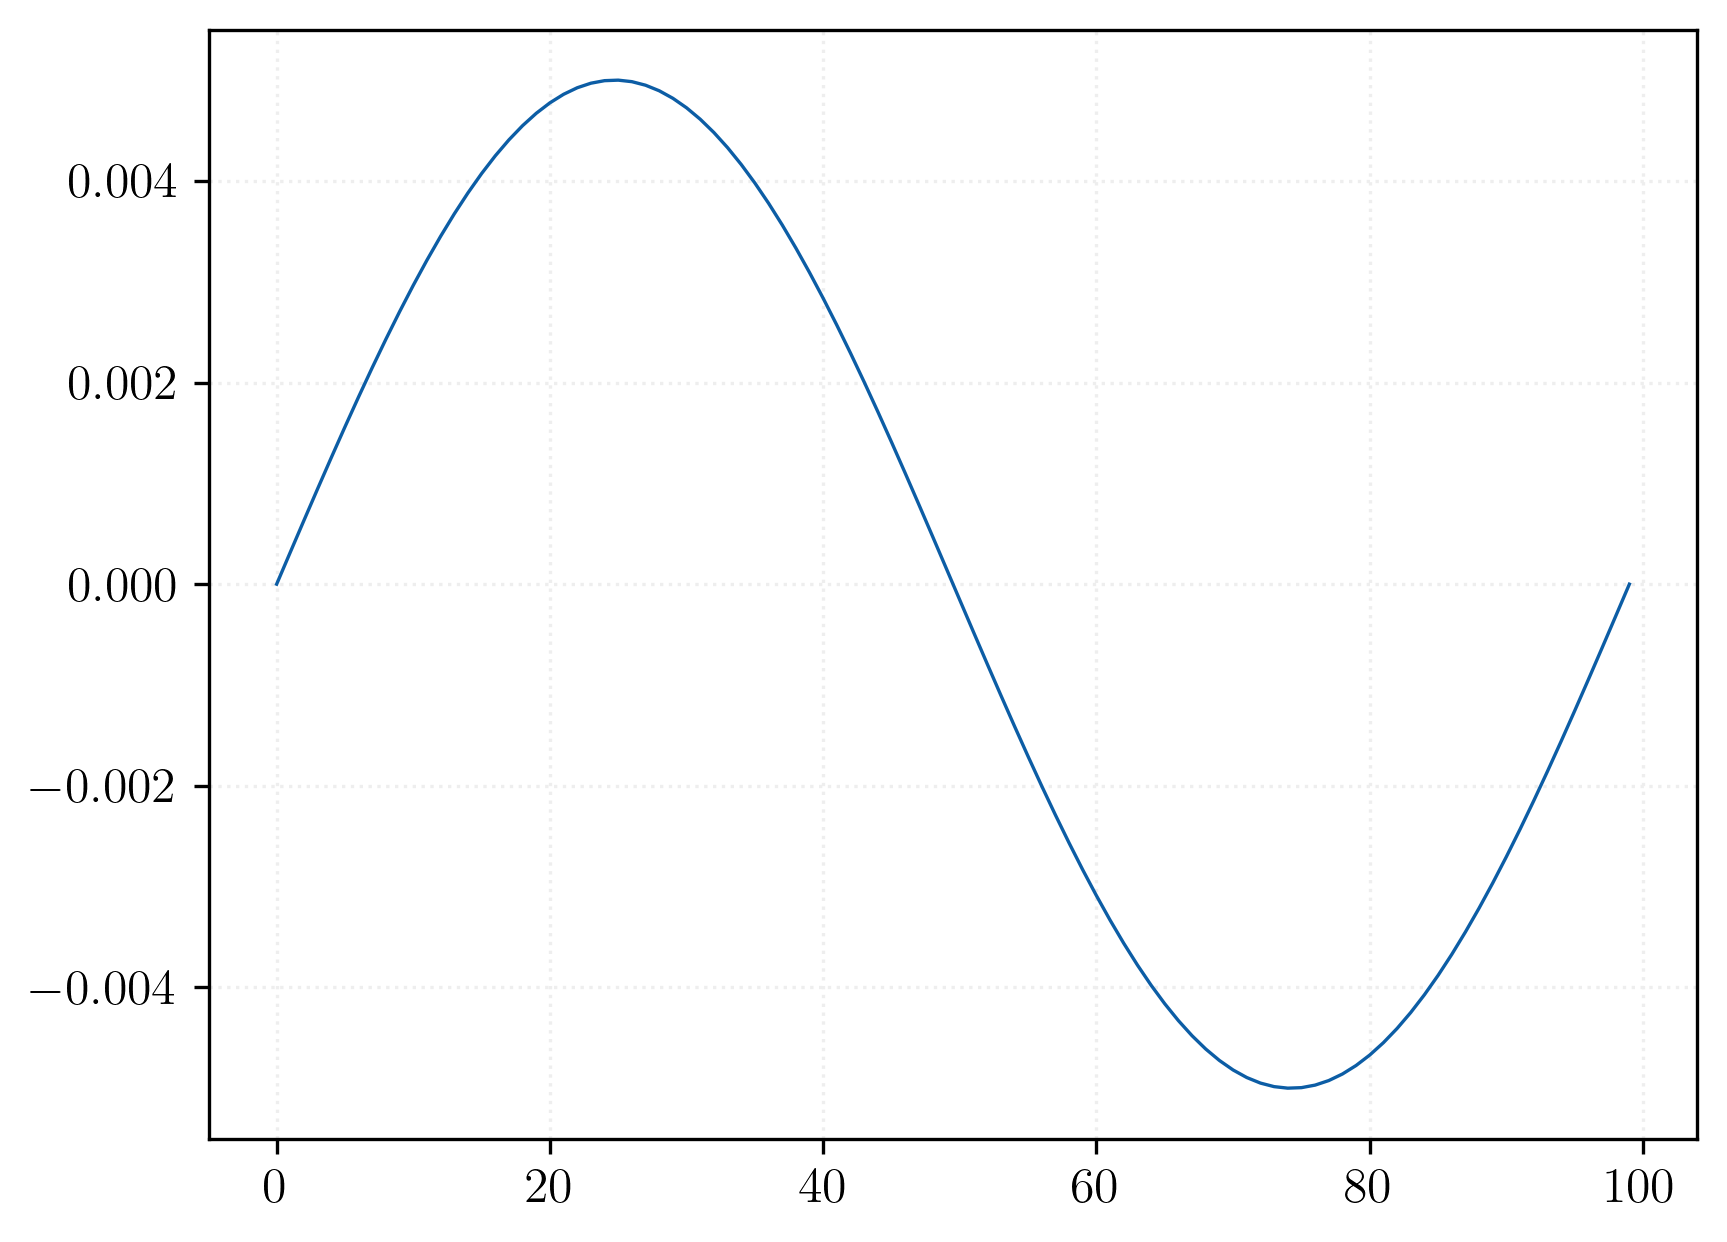

In [5]:

strain = 0.005*sin(linspace(0, 2.0*pi, 100))
plt.plot(strain)

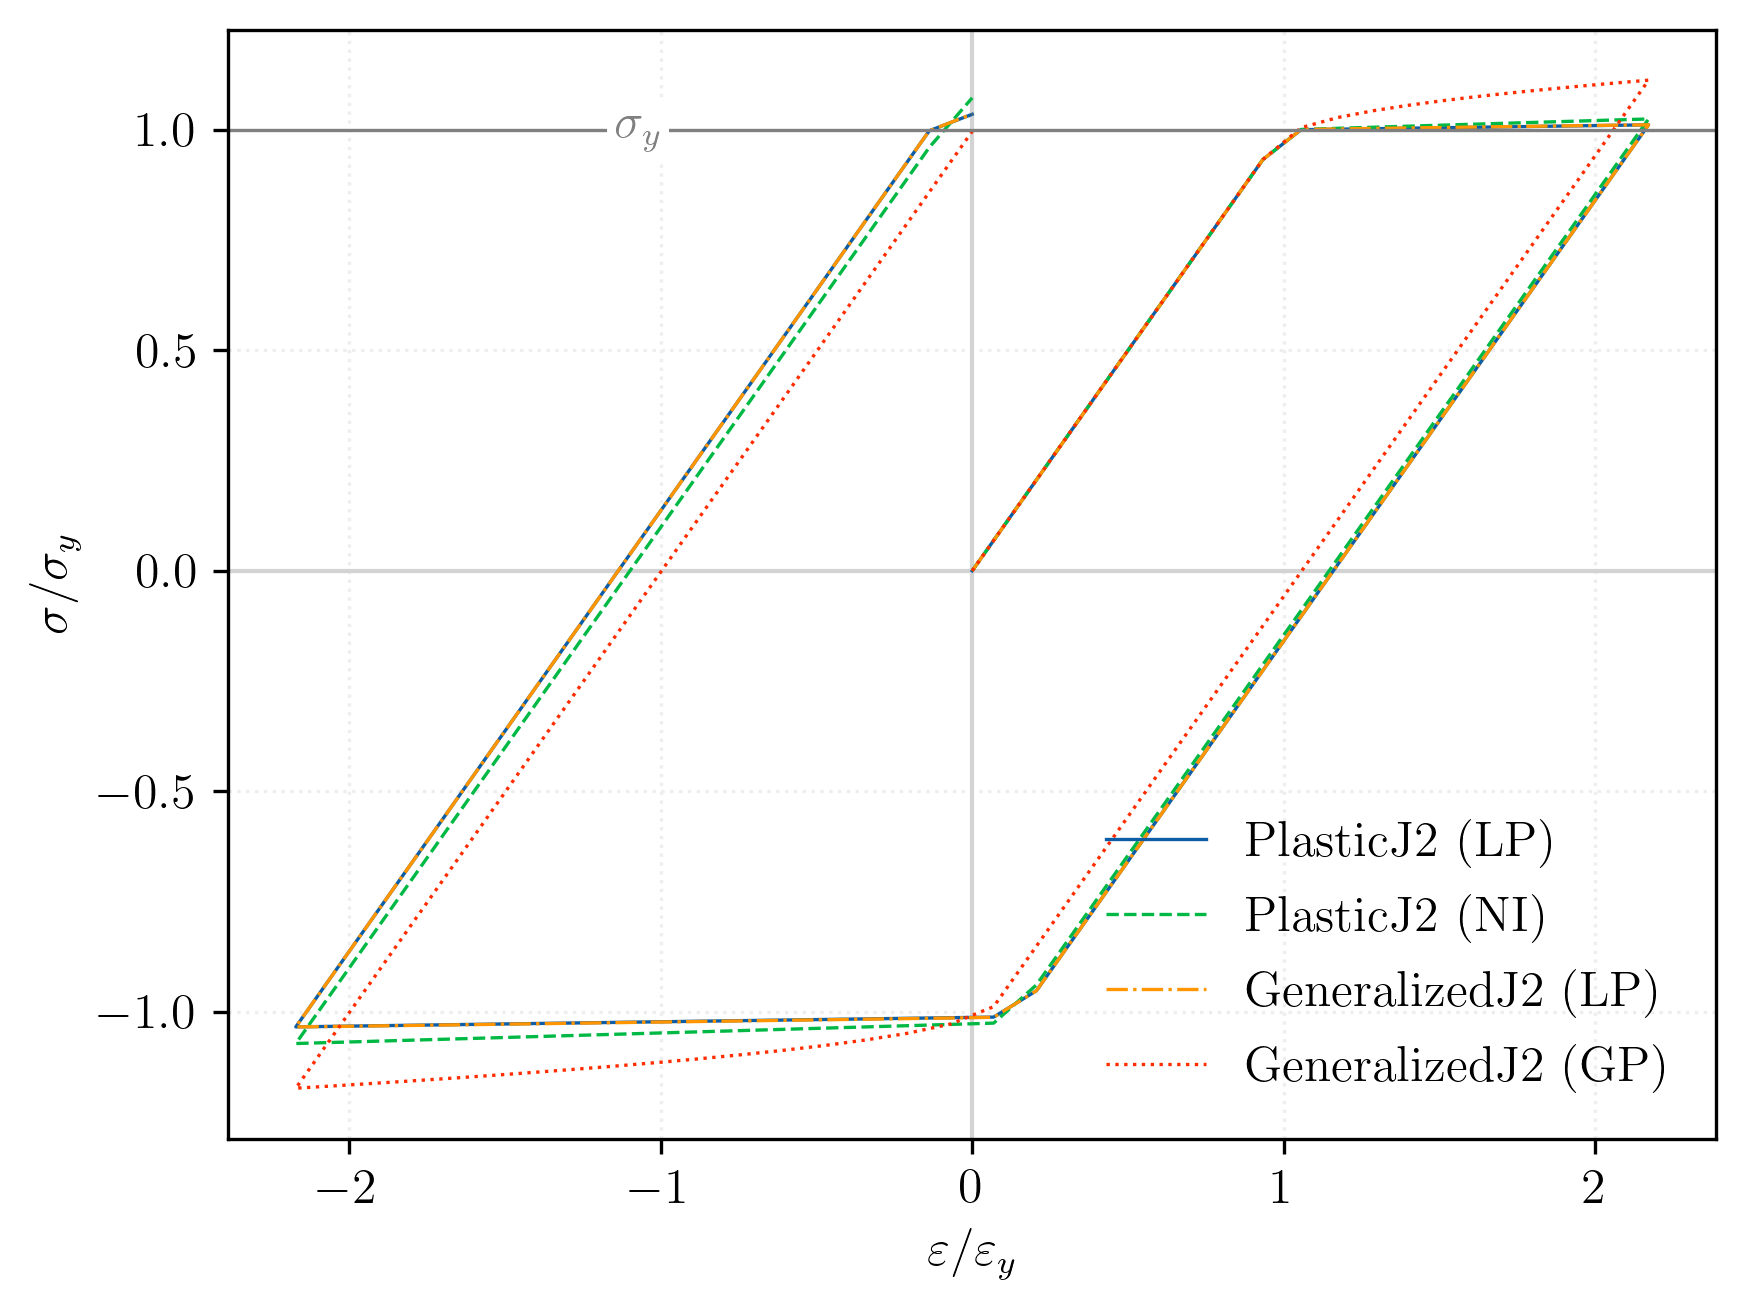

In [6]:

# create a figure to plot
fig, ax = plt.subplots()

LineStyles = iter(["-", "--", "-.", ":"])

ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)

for name,material in Materials.items():
    with material as tmp:
        stress = []
        for e in strain:
            stress.append(tmp.getStress(e, commit=True)/Fy)
    ax.plot(strain/(Fy/Es), stress, next(LineStyles), label=name)

ax.axhline(y=1, color='gray', linestyle='-')
ax.text(-1, 1, r"$\sigma_y$", color='gray', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))
ax.legend()
ax.set_xlabel(r"$\varepsilon/\varepsilon_y$")
ax.set_ylabel(r"$\sigma/\sigma_y$");

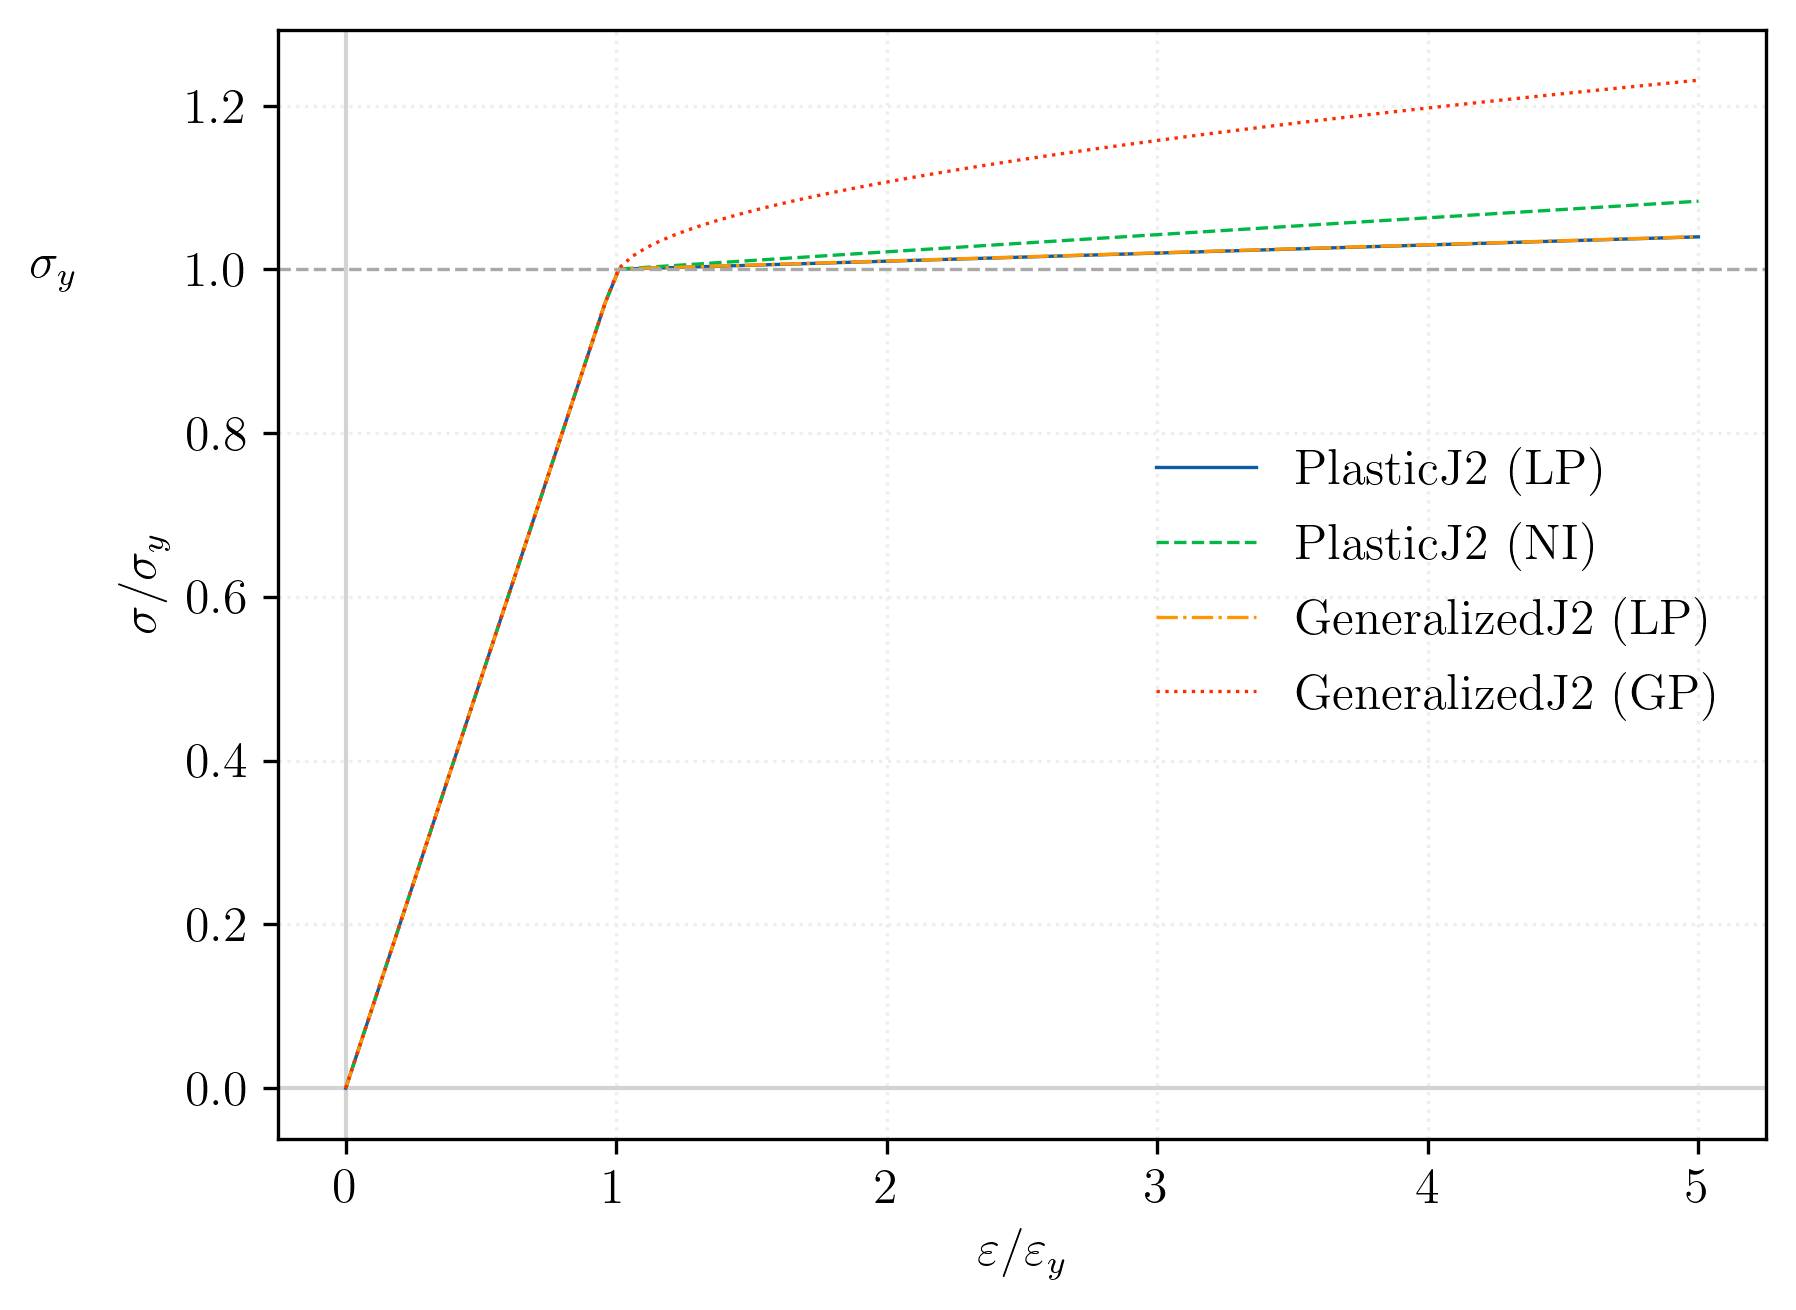

In [7]:
fig, ax = plt.subplots()
LineStyles = iter(["-", "--", "-.", ":"])
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)

strain = np.linspace(0, Fy/Es*5, 100)

for name,material in Materials.items():
    with material as tmp:
        stress = []
        for e in strain:
            stress.append(tmp.getStress(e, commit=True)/Fy)
    ln = ax.plot(strain/(Fy/Es), stress, next(LineStyles), label=name)


# Draw a horizontal line at the yield stress Fy
ax.axhline(y=1, color='darkgrey', linestyle='--')
ax.text(-1, 1, r"$\sigma_y$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_y$")
ax.set_ylabel(r"$\sigma/\sigma_y$")
ax.legend();

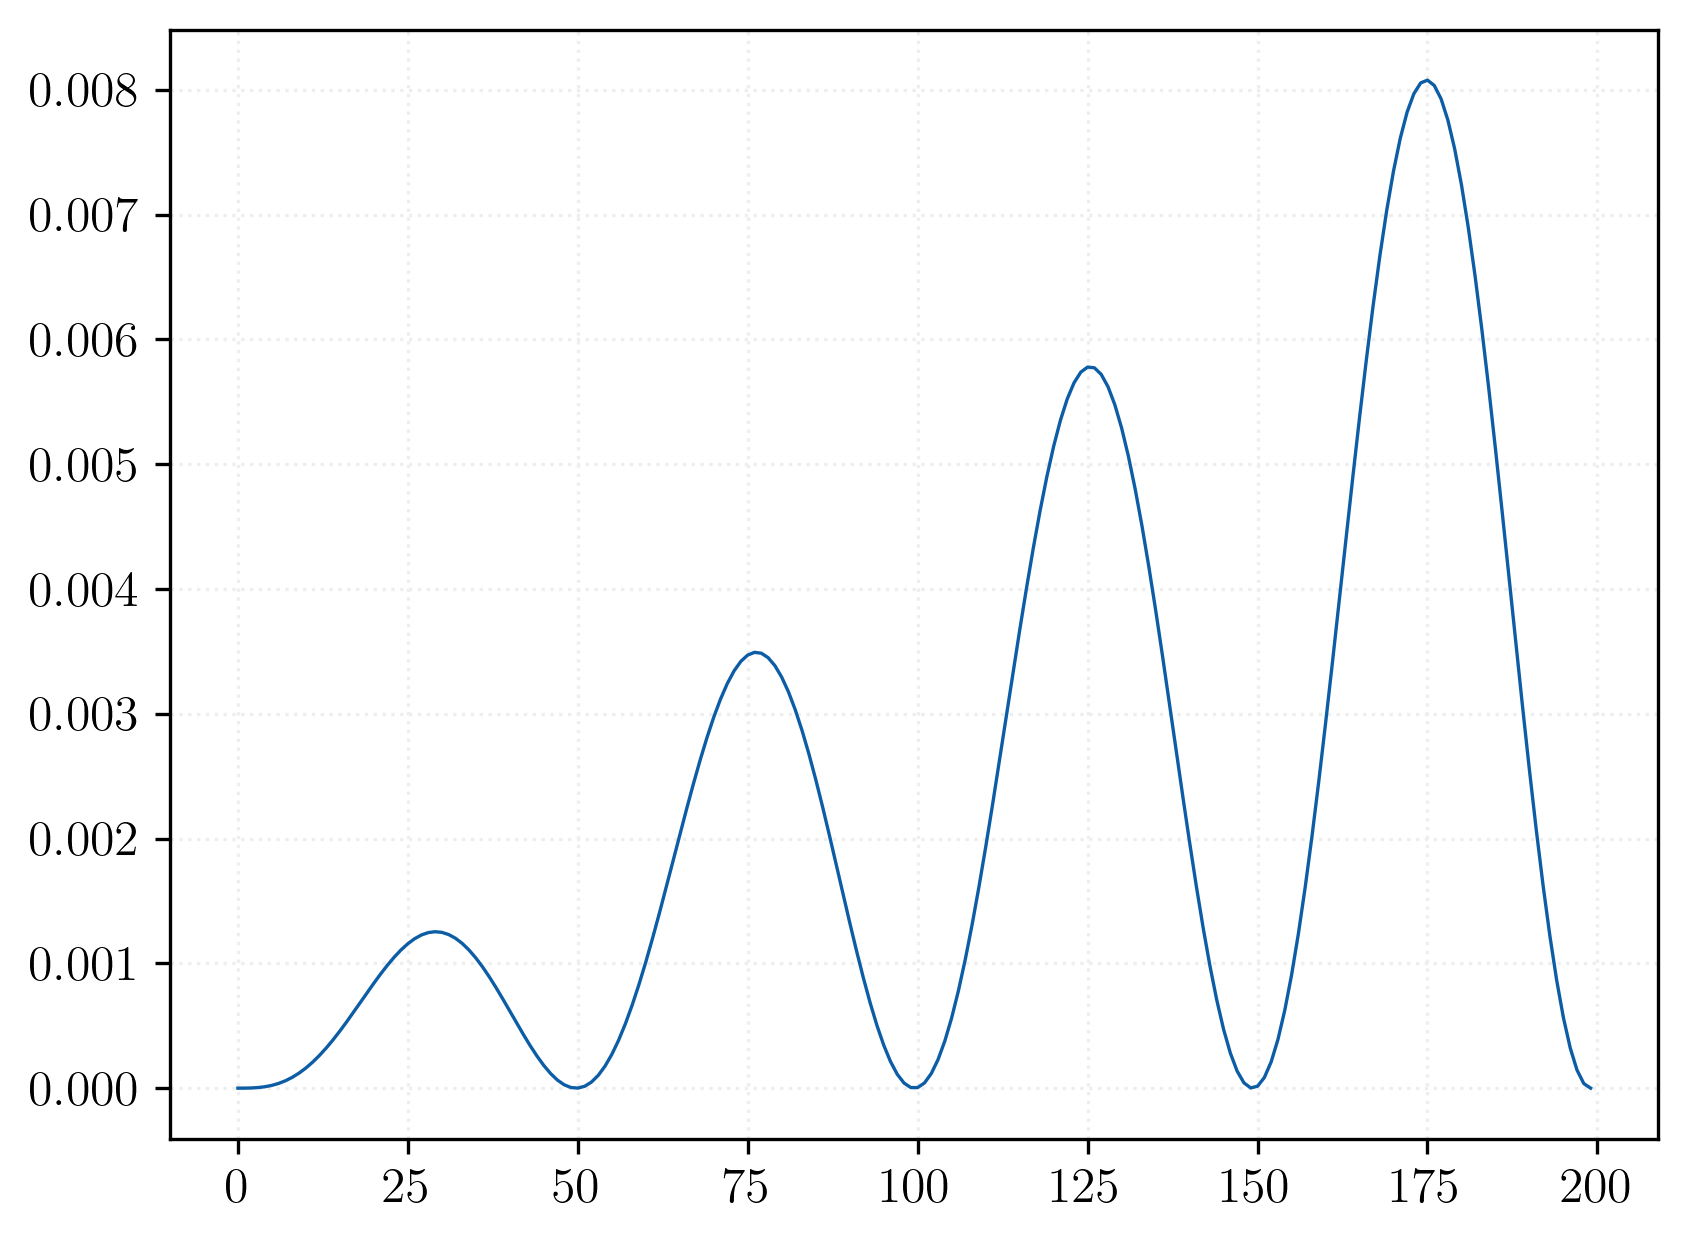

In [8]:

strain = np.linspace(0, 4*Fy/Es, 200)*sin(linspace(0, 4.0*pi, 200))**2
# strain = 4*Fy/Es*sin(linspace(0, 4.0*pi, 100))**2
plt.plot(strain)

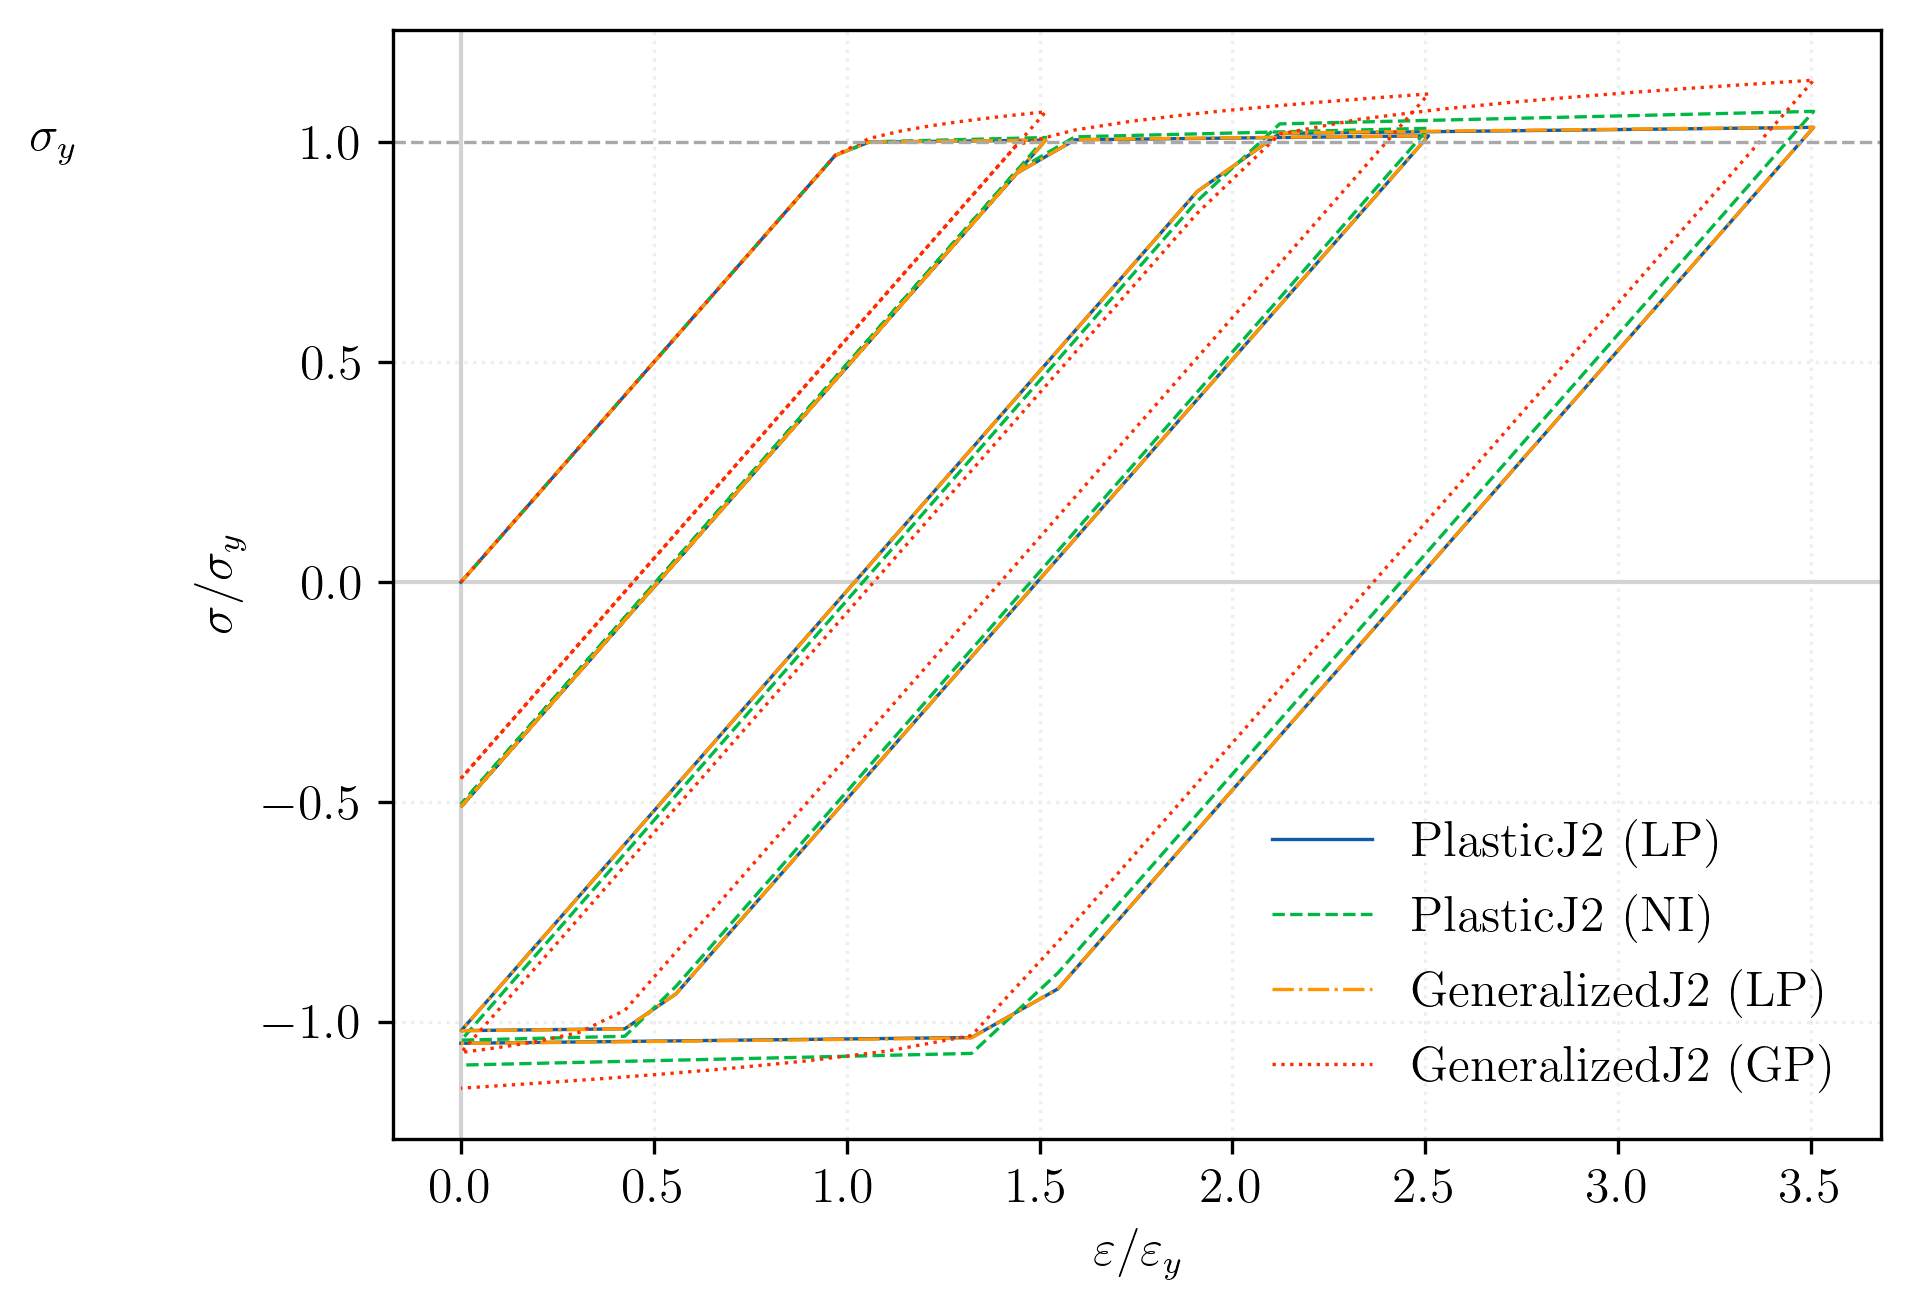

In [9]:

LineStyles = iter(["-", "--", "-.", ":"])
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)


for name,material in Materials.items():
    with material as tmp:
        stress = []
        for e in strain:
            stress.append(tmp.getStress(e, commit=True)/Fy)
    ax.plot(strain/(Fy/Es), stress, next(LineStyles), label=name)


# Draw a horizontal line at the yield stress Fy
ax.axhline(y=1, color='darkgrey', linestyle='--')
ax.text(-1, 1, r"$\sigma_y$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_y$")
ax.set_ylabel(r"$\sigma/\sigma_y$")
ax.legend();